In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.shape

(8807, 12)

In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
#To remove all the duplicates

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df['country'] = df.fillna('Unknown', inplace=True)
df['director'] = df.fillna('Unknown', inplace=True)

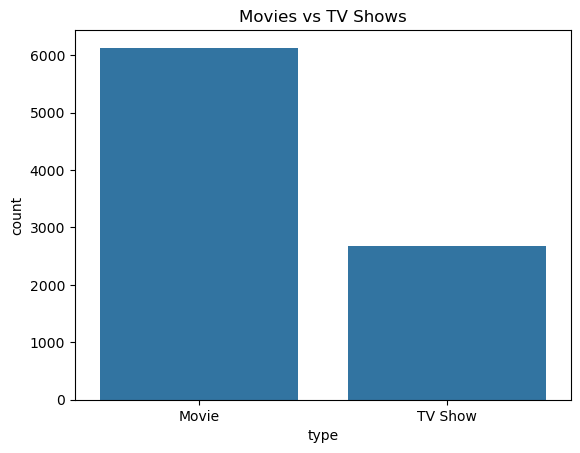

In [10]:
sns.countplot(x = 'type', data = df)
plt.title("Movies vs TV Shows")
plt.show()

In [11]:
#Netflix contains significantly more Movies than TV Shows, showing a stronger focus on movie content distribution.

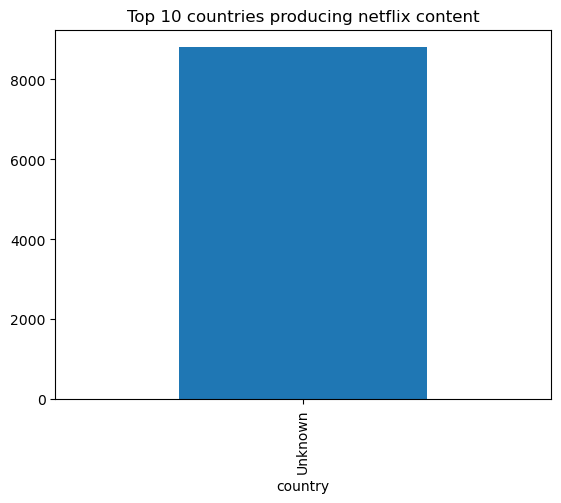

In [12]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind = 'bar')
plt.title("Top 10 countries producing netflix content")
plt.show()

In [13]:
#The United States produces the highest amount of Netflix content, followed by India and the United Kingdom.

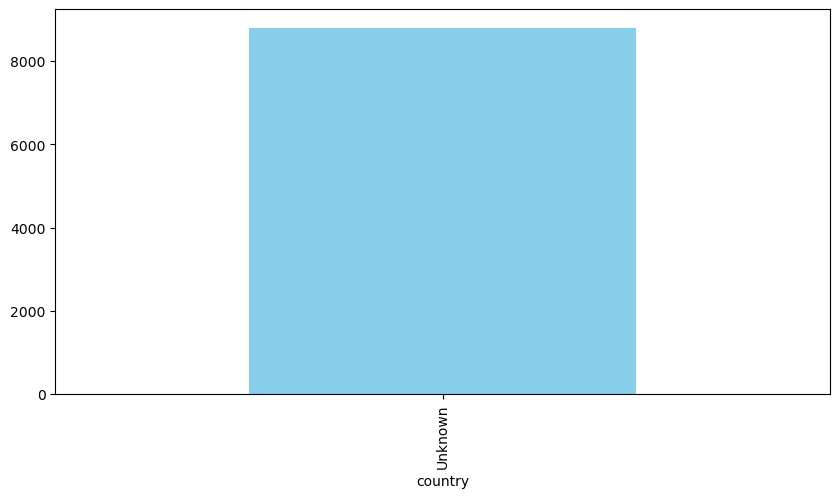

In [14]:
if top_countries.empty:
    print("No valid country data available to plot.")
else:
    plt.figure(figsize=(10, 5))
    top_countries.plot(kind="bar", color="skyblue")
    plt.show()

In [15]:
top_countries = (
    df["country"]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
)

top_countries = top_countries[~top_countries.isin(["", "Unknown"])]
top_countries = top_countries.value_counts().head(10)

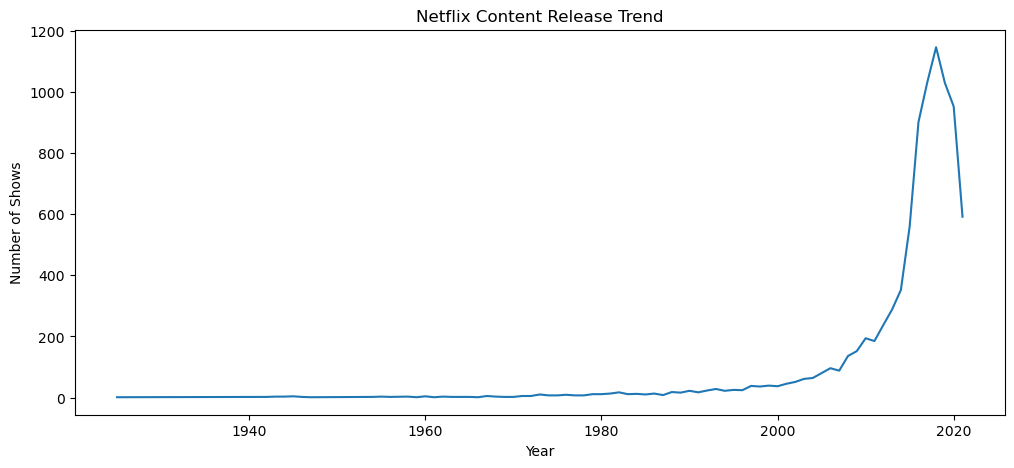

In [16]:
# Release trend anlysis

df["release_year"].value_counts().sort_index().plot(figsize=(12,5))

plt.title("Netflix Content Release Trend")

plt.xlabel("Year")

plt.ylabel("Number of Shows")

plt.show()

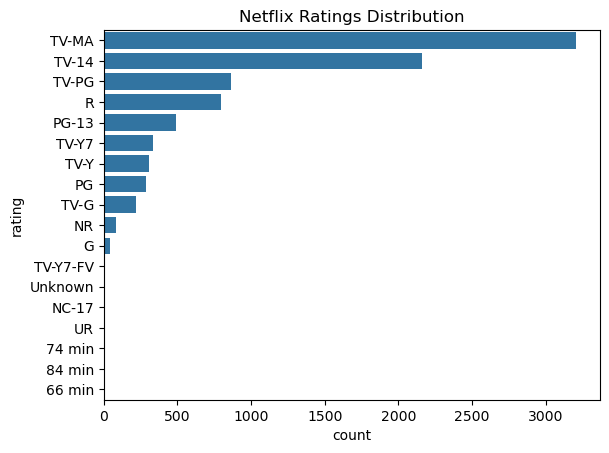

In [17]:
# Rating Analysis
sns.countplot(
    y="rating",
    data=df,
    order=df["rating"].value_counts().index
)

plt.title("Netflix Ratings Distribution")

plt.show()

Key Insights
Netflix contains more movies than TV shows.
Content production increased rapidly after 2015.
USA produces the highest Netflix content.
TV-MA is the most common rating category.